# 1 &middot; Feature extraction, extents, and elongation

A first sanity check on the core of `gridfeatures`: threshold a field, label the connected blobs, and describe each one. We plant three shapes we already know the answer for &mdash; a **disk**, a **tilted ellipse**, and a **near-line** &mdash; and confirm the package recovers their extent and elongation, then overlay the *fitted* ellipse so you can see it hug the footprint.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Kilometres per degree (same constant the package uses for its tangent plane).
KM_PER_DEG = math.pi * 6371.0 / 180.0


def add_ellipse(field, lat2d, lon2d, clat, clon, a_deg, b_deg, angle_deg, val):
    """Paint an elliptical blob (value `val`) into `field`.

    `a_deg`/`b_deg` are the semi-axes; longitude offsets are scaled by
    cos(clat) so the blob is round in ground distance, not in raw degrees.
    `angle_deg` tilts the major axis counterclockwise from east.
    """
    th = math.radians(angle_deg)
    dy = lat2d - clat
    dx = (lon2d - clon) * math.cos(math.radians(clat))
    xr = dx * math.cos(th) + dy * math.sin(th)
    yr = -dx * math.sin(th) + dy * math.cos(th)
    field[(xr / a_deg) ** 2 + (yr / b_deg) ** 2 <= 1.0] = val


def fitted_ellipse_lonlat(f, lat0, lon0, n=240):
    """Trace the package's fitted ellipse for feature `f` in lon/lat.

    Uses the public shape stats (major/minor axis km + orientation) and a
    supplied centre, so it draws exactly what `gridfeatures` measured.
    """
    from gridfeatures import stats
    a = stats.major_axis_km(f)
    b = stats.minor_axis_km(f)
    th = math.radians(stats.orientation_deg(f))
    t = np.linspace(0, 2 * np.pi, n)
    xk, yk = (a / 2) * np.cos(t), (b / 2) * np.sin(t)
    xr = xk * math.cos(th) - yk * math.sin(th)
    yr = xk * math.sin(th) + yk * math.cos(th)
    lon = lon0 + xr / (KM_PER_DEG * math.cos(math.radians(lat0)))
    lat = lat0 + yr / KM_PER_DEG
    return lon, lat


## Build a synthetic field

A regular lat/lon grid near the equator with three painted blobs (value `5`, background `0`). Longitude offsets are cos(lat)-scaled so the disk is genuinely round on the ground.

In [2]:
from gridfeatures import stats
from gridfeatures.config import Config
from gridfeatures.runner import extract_features

res = 0.25
lat = np.arange(-8.0, 8.0 + res, res)
lon = np.arange(-12.0, 12.0 + res, res)
lats2d, lons2d = np.meshgrid(lat, lon, indexing="ij")

field = np.zeros_like(lats2d)
add_ellipse(field, lats2d, lons2d, clat=-4.0, clon=-8.0, a_deg=2.0, b_deg=2.0,  angle_deg=0.0,   val=5.0)   # disk
add_ellipse(field, lats2d, lons2d, clat=0.0,  clon=0.0,  a_deg=5.0, b_deg=1.5,  angle_deg=30.0,  val=5.0)   # tilted ellipse
add_ellipse(field, lats2d, lons2d, clat=5.0,  clon=7.0,  a_deg=6.0, b_deg=0.35, angle_deg=-60.0, val=5.0)   # near-line

cfg = Config(files="mem", variable="x", threshold=1.0, min_size=4,
             statistics={"size": stats.size})
feats = extract_features(field, lats2d, lons2d, cfg, source="mem")
print(f"detected {len(feats)} features")

detected 3 features


## What did it measure?

For each feature: pixel size, the four cardinal extents, and the equivalent-ellipse shape (`eccentricity` in [0, 1), `elongation` = major/minor, axis lengths in km, and orientation in degrees counterclockwise from east).

In [3]:
import pandas as pd

rows = []
for f in feats:
    rows.append({
        "size": stats.size(f),
        "S": round(stats.south_extent(f), 2), "N": round(stats.north_extent(f), 2),
        "W": round(stats.west_extent(f), 2),  "E": round(stats.east_extent(f), 2),
        "eccentricity": round(stats.eccentricity(f), 3),
        "elongation": round(stats.elongation(f), 2),
        "major_km": round(stats.major_axis_km(f), 0),
        "minor_km": round(stats.minor_axis_km(f), 0),
        "orient_deg": round(stats.orientation_deg(f), 1),
    })
tbl = pd.DataFrame(rows).sort_values("eccentricity").reset_index(drop=True)
tbl

,size,S,N,W,E,eccentricity,elongation,major_km,minor_km,orient_deg
0,197,-6.00,-2.00,-10.00,-6.00,0.070,1.00,441.0,439.0,90.0
1,373,-2.75,2.75,-4.25,4.25,0.956,3.39,1116.0,329.0,30.5
2,93,0.25,8.00,5.00,9.75,0.997,13.27,1109.0,84.0,-59.9


## The fitted ellipse, drawn over the footprint

Each dashed curve is reconstructed purely from the public shape stats (`major_axis_km`, `minor_axis_km`, `orientation_deg`) centred on the feature. If the maths is right, it traces the blob it came from.

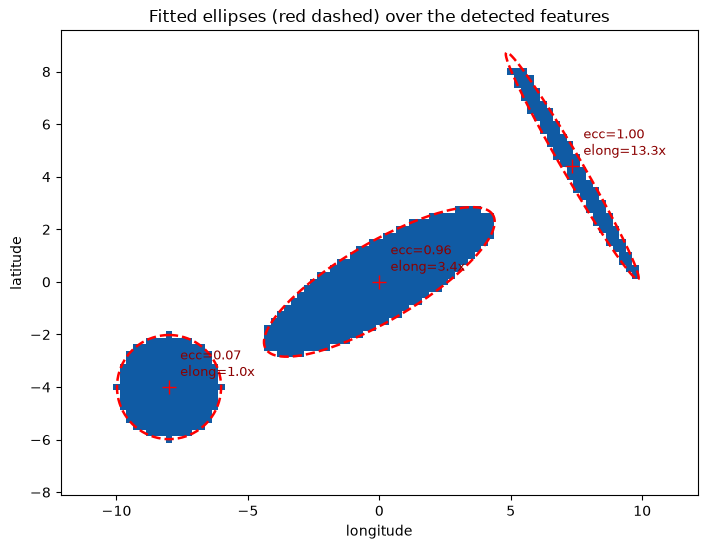

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.6))
bg = np.where(field > 0, field, np.nan)
ax.pcolormesh(lon, lat, bg, cmap="Blues", shading="auto", vmin=0, vmax=6)

for f in feats:
    lat0, lon0 = float(f.lats.mean()), float(f.lons.mean())
    elon, elat = fitted_ellipse_lonlat(f, lat0, lon0)
    ax.plot(elon, elat, "r--", lw=1.8)
    ax.plot(lon0, lat0, "r+", ms=10)
    ax.annotate(f"ecc={stats.eccentricity(f):.2f}\nelong={stats.elongation(f):.1f}x",
                (lon0, lat0), textcoords="offset points", xytext=(8, 8),
                fontsize=9, color="darkred")

ax.set_aspect(1.0 / math.cos(0))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Fitted ellipses (red dashed) over the detected features")
plt.tight_layout(); plt.show()

## Do the numbers match what we planted?


In [5]:
disk = min(feats, key=lambda f: stats.eccentricity(f))
line = max(feats, key=lambda f: stats.eccentricity(f))
tilt = [f for f in feats if f not in (disk, line)][0]

assert stats.eccentricity(disk) < 0.25,           "disk should be near-circular"
assert stats.eccentricity(line) > 0.98,           "near-line should be very eccentric"
assert 0.9 < stats.eccentricity(tilt) < 0.98,      "tilted ellipse sits in between"
assert stats.elongation(line) > stats.elongation(tilt) > stats.elongation(disk)
# The tilted ellipse was planted at +30 deg from east; orientation recovers it.
assert abs(stats.orientation_deg(tilt) - 30.0) < 6.0

print("disk : ecc={:.3f}  elong={:.2f}".format(stats.eccentricity(disk), stats.elongation(disk)))
print("tilt : ecc={:.3f}  elong={:.2f}  orient={:.1f} deg (planted 30)".format(
      stats.eccentricity(tilt), stats.elongation(tilt), stats.orientation_deg(tilt)))
print("line : ecc={:.3f}  elong={:.2f}".format(stats.eccentricity(line), stats.elongation(line)))
print("\nAll checks passed.")

disk : ecc=0.070  elong=1.00
tilt : ecc=0.956  elong=3.39  orient=30.5 deg (planted 30)
line : ecc=0.997  elong=13.27

All checks passed.
